In [ ]:
# ==========================================
# CUSTOMER CHURN PREDICTION
# European Banking Dataset
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ==========================================
# 2. DATA INGESTION & INITIAL INSPECTION
# ==========================================

# Load the dataset
df = pd.read_csv("Churn.scv.csv")

# Display basic information
print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display first 5 records
df.head()

Dataset loaded successfully!
Number of rows: 10000
Number of columns: 14


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# ==========================================
# 3. DATA VALIDATION
# ==========================================

print("----- DATA TYPES -----")
print(df.dtypes)

print("\n----- MISSING VALUES -----")
print(df.isnull().sum())

print("\n----- DUPLICATE RECORDS -----")
print("Number of duplicate rows:", df.duplicated().sum())

print("\n----- UNIQUE VALUES IN CATEGORICAL/BINARY FIELDS -----")

for col in ["Geography", "Gender", "HasCrCard", "IsActiveMember", "Exited"]:
    print(f"\n{col}:")
    print(df[col].unique())

print("\n----- TARGET VARIABLE: EXITED -----")
print(df["Exited"].value_counts())

print("\n----- TARGET VARIABLE (%): -----")
print(df["Exited"].value_counts(normalize=True) * 100)

----- DATA TYPES -----
Year                 int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

----- MISSING VALUES -----
Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

----- DUPLICATE RECORDS -----
Number of duplicate rows: 0

----- UNIQUE VALUES IN CATEGORICAL/BINARY FIELDS -----

Geography:
['France' 'Spain' 'Germany']

Gender:
['Female' 'Male']

HasCrCard:
[1 0]

IsActiveMember:
[1 0]

Exited:
[1 0]

----- TARG

In [ ]:
# ==========================================
# 4. DATA CLEANING & PREPARATION
# ==========================================

# Create a copy of the original dataset
df_clean = df.copy()

# Remove non-analytical field
if "Surname" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Surname"])

# Check the remaining columns
print("Columns after cleaning:")
print(df_clean.columns.tolist())

print("\nDataset shape after cleaning:")
print(df_clean.shape)

# Check for missing values
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

# Display cleaned dataset
df_clean.head()

Columns after cleaning:
['Year', 'CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Dataset shape after cleaning:
(10000, 13)

Missing values after cleaning:
Year               0
CustomerId         0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


,Year,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# ==========================================
# 5. CUSTOMER SEGMENTATION DESIGN
# ==========================================

# 1. Age Segmentation
df_clean["Age_Group"] = pd.cut(
    df_clean["Age"],
    bins=[0, 29, 45, 60, float("inf")],
    labels=["<30", "30-45", "46-60", "60+"]
)

# 2. Credit Score Segmentation
df_clean["Credit_Score_Group"] = pd.cut(
    df_clean["CreditScore"],
    bins=[0, 579, 669, float("inf")],
    labels=["Low", "Medium", "High"]
)

# 3. Tenure Segmentation
df_clean["Tenure_Group"] = pd.cut(
    df_clean["Tenure"],
    bins=[-1, 2, 6, float("inf")],
    labels=["New", "Mid-term", "Long-term"]
)

# 4. Balance Segmentation
df_clean["Balance_Group"] = pd.cut(
    df_clean["Balance"],
    bins=[-1, 0, 50000, float("inf")],
    labels=["Zero-balance", "Low-balance", "High-balance"]
)

# Display the new segmentation fields
print("Segmentation fields created successfully!\n")

print("Age Groups:")
print(df_clean["Age_Group"].value_counts().sort_index())

print("\nCredit Score Groups:")
print(df_clean["Credit_Score_Group"].value_counts().sort_index())

print("\nTenure Groups:")
print(df_clean["Tenure_Group"].value_counts().sort_index())

print("\nBalance Groups:")
print(df_clean["Balance_Group"].value_counts().sort_index())

Segmentation fields created successfully!

Age Groups:
Age_Group
<30      1641
30-45    6248
46-60    1647
60+       464
Name: count, dtype: int64

Credit Score Groups:
Credit_Score_Group
Low       2362
Medium    3331
High      4307
Name: count, dtype: int64

Tenure Groups:
Tenure_Group
New          2496
Mid-term     3977
Long-term    3527
Name: count, dtype: int64

Balance Groups:
Balance_Group
Zero-balance    3617
Low-balance       75
High-balance    6308
Name: count, dtype: int64


Total Customers: 10000
Churned Customers: 2037
Retained Customers: 7963
Overall Churn Rate: 20.37%


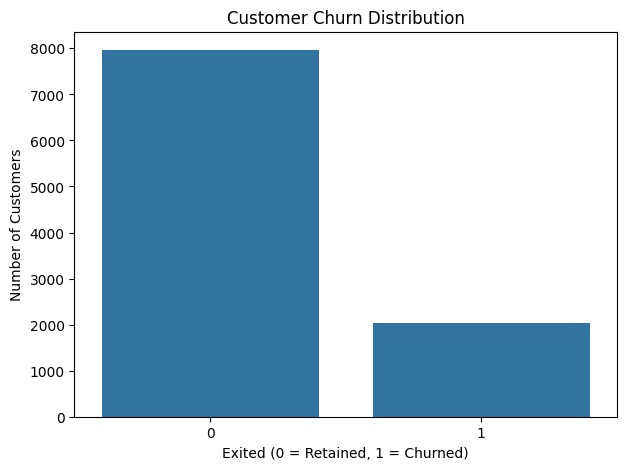

In [ ]:
# ==========================================
# 6. OVERALL CHURN DISTRIBUTION & KPI
# ==========================================

total_customers = len(df_clean)
churned_customers = df_clean["Exited"].sum()

overall_churn_rate = (churned_customers / total_customers) * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", total_customers - churned_customers)
print(f"Overall Churn Rate: {overall_churn_rate:.2f}%")

# Churn distribution
plt.figure(figsize=(7,5))
sns.countplot(data=df_clean, x="Exited")
plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Retained, 1 = Churned)")
plt.ylabel("Number of Customers")
plt.show()

  Geography  count  sum      mean  Churn_Rate_%
0    France   5014  810  0.161548     16.154767
1   Germany   2509  814  0.324432     32.443204
2     Spain   2477  413  0.166734     16.673395


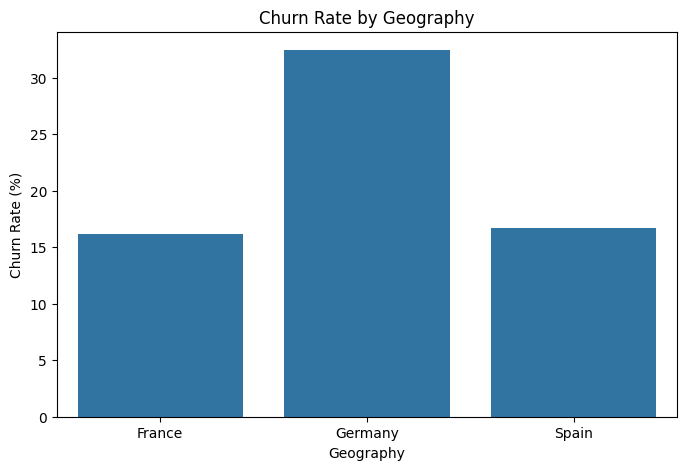

In [ ]:
# ==========================================
# 7. GEOGRAPHY-WISE CHURN ANALYSIS
# ==========================================

geo_churn = (
    df_clean.groupby("Geography")["Exited"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

geo_churn["Churn_Rate_%"] = geo_churn["mean"] * 100

print(geo_churn)

plt.figure(figsize=(8,5))
sns.barplot(data=geo_churn, x="Geography", y="Churn_Rate_%")
plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")
plt.show()

  Age_Group    Exited  Churn_Rate_%
0       <30  0.075564      7.556368
1     30-45  0.153009     15.300896
2     46-60  0.511233     51.123254
3       60+  0.247845     24.784483


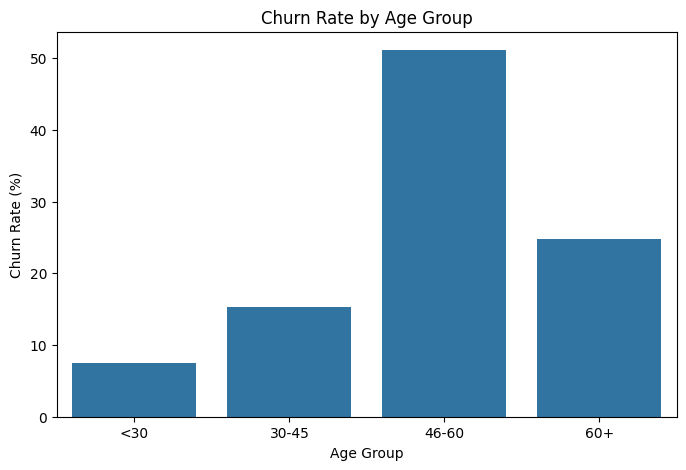

In [ ]:
# ==========================================
# 8. AGE GROUP CHURN ANALYSIS
# ==========================================

age_churn = (
    df_clean.groupby("Age_Group", observed=True)["Exited"]
    .mean()
    .reset_index()
)

age_churn["Churn_Rate_%"] = age_churn["Exited"] * 100

print(age_churn)

plt.figure(figsize=(8,5))
sns.barplot(data=age_churn, x="Age_Group", y="Churn_Rate_%")
plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.show()

  Tenure_Group    Exited  Churn_Rate_%
0          New  0.211538     21.153846
1     Mid-term  0.206437     20.643701
2    Long-term  0.195067     19.506663


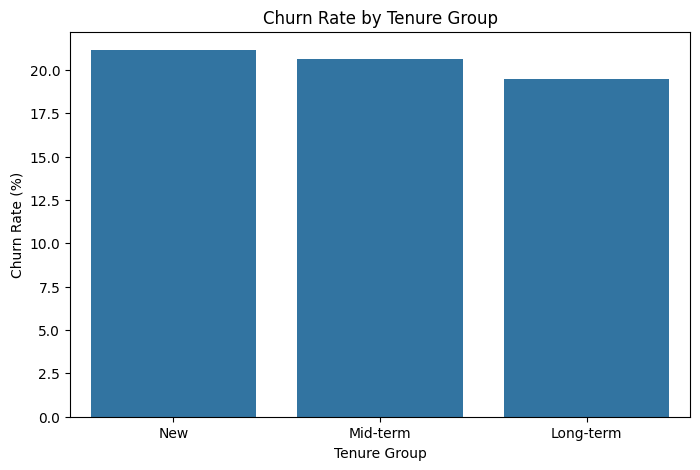

In [ ]:
# ==========================================
# 9. TENURE-WISE CHURN ANALYSIS
# ==========================================

tenure_churn = (
    df_clean.groupby("Tenure_Group", observed=True)["Exited"]
    .mean()
    .reset_index()
)

tenure_churn["Churn_Rate_%"] = tenure_churn["Exited"] * 100

print(tenure_churn)

plt.figure(figsize=(8,5))
sns.barplot(data=tenure_churn, x="Tenure_Group", y="Churn_Rate_%")
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.show()

  Credit_Score_Group    Exited  Churn_Rate_%
0                Low  0.220152     22.015241
1             Medium  0.205644     20.564395
2               High  0.193174     19.317390


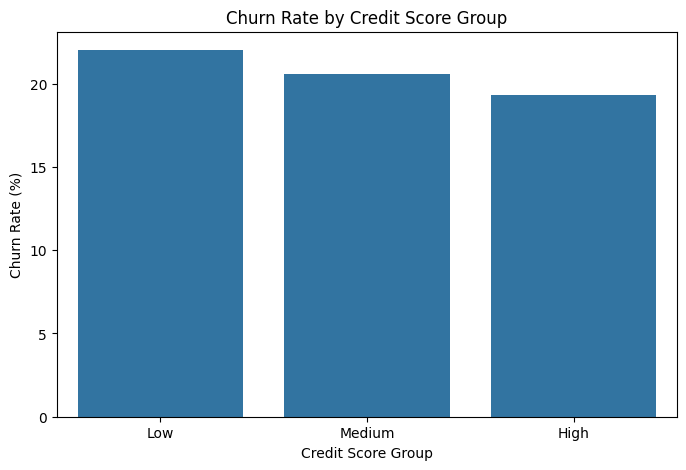

In [ ]:
# ==========================================
# 10. CREDIT SCORE CHURN ANALYSIS
# ==========================================

credit_churn = (
    df_clean.groupby("Credit_Score_Group", observed=True)["Exited"]
    .mean()
    .reset_index()
)

credit_churn["Churn_Rate_%"] = credit_churn["Exited"] * 100

print(credit_churn)

plt.figure(figsize=(8,5))
sns.barplot(data=credit_churn, x="Credit_Score_Group", y="Churn_Rate_%")
plt.title("Churn Rate by Credit Score Group")
plt.xlabel("Credit Score Group")
plt.ylabel("Churn Rate (%)")
plt.show()

  Balance_Group    Exited  Churn_Rate_%
0  Zero-balance  0.138236     13.823611
1   Low-balance  0.346667     34.666667
2  High-balance  0.239537     23.953710


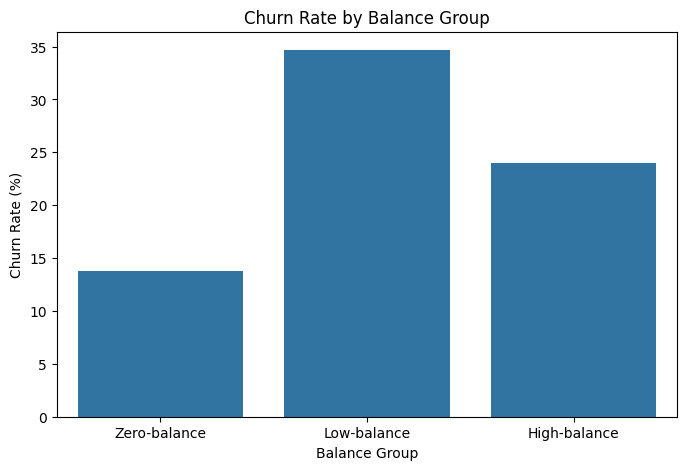

In [ ]:
# ==========================================
# 11. BALANCE GROUP CHURN ANALYSIS
# ==========================================

balance_churn = (
    df_clean.groupby("Balance_Group", observed=True)["Exited"]
    .mean()
    .reset_index()
)

balance_churn["Churn_Rate_%"] = balance_churn["Exited"] * 100

print(balance_churn)

plt.figure(figsize=(8,5))
sns.barplot(data=balance_churn, x="Balance_Group", y="Churn_Rate_%")
plt.title("Churn Rate by Balance Group")
plt.xlabel("Balance Group")
plt.ylabel("Churn Rate (%)")
plt.show()

Gender-wise Churn:
   Gender    Exited  Churn_Rate_%
0  Female  0.250715     25.071539
1    Male  0.164559     16.455928

Activity-wise Churn:
   IsActiveMember    Exited  Churn_Rate_%
0               0  0.268509     26.850897
1               1  0.142691     14.269074


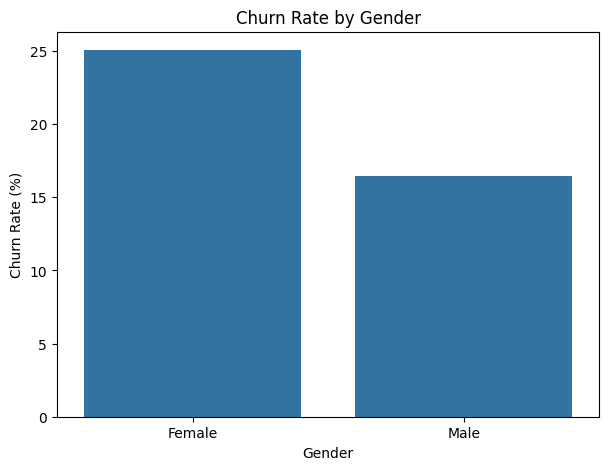

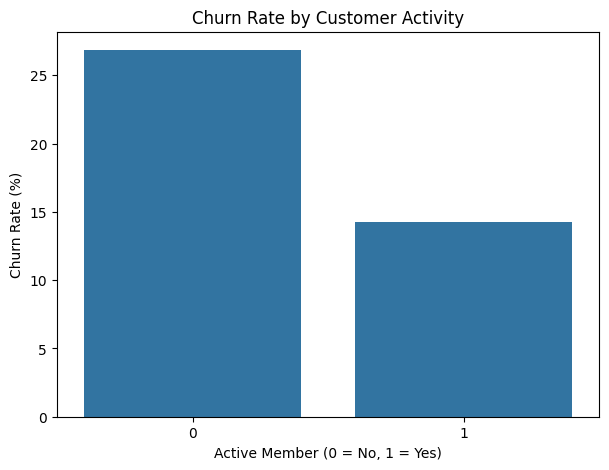

In [ ]:
# ==========================================
# 12. GENDER & ACTIVITY ANALYSIS
# ==========================================

# Gender churn
gender_churn = (
    df_clean.groupby("Gender")["Exited"]
    .mean()
    .reset_index()
)

gender_churn["Churn_Rate_%"] = gender_churn["Exited"] * 100

print("Gender-wise Churn:")
print(gender_churn)

# Activity churn
activity_churn = (
    df_clean.groupby("IsActiveMember")["Exited"]
    .mean()
    .reset_index()
)

activity_churn["Churn_Rate_%"] = activity_churn["Exited"] * 100

print("\nActivity-wise Churn:")
print(activity_churn)

# Visualization
plt.figure(figsize=(7,5))
sns.barplot(data=gender_churn, x="Gender", y="Churn_Rate_%")
plt.title("Churn Rate by Gender")
plt.ylabel("Churn Rate (%)")
plt.show()

plt.figure(figsize=(7,5))
sns.barplot(data=activity_churn, x="IsActiveMember", y="Churn_Rate_%")
plt.title("Churn Rate by Customer Activity")
plt.xlabel("Active Member (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")
plt.show()

High-Value Customer Churn Analysis:
   High_Value_Customer    Exited  Churn_Rate_%
0                    0  0.192667     19.266667
1                    1  0.236800     23.680000

High-value balance threshold: 127644.24


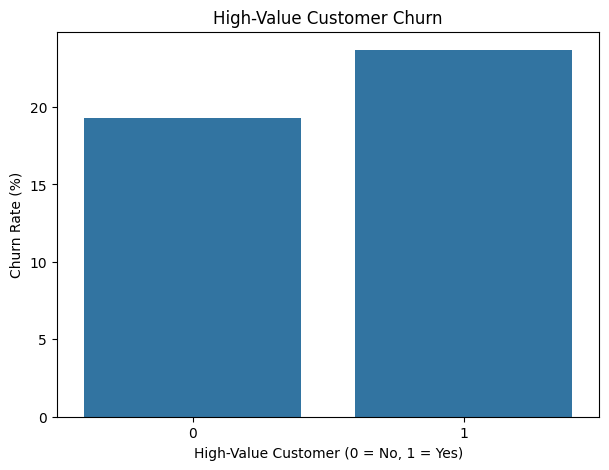

In [ ]:
# ==========================================
# 13. HIGH-VALUE CUSTOMER CHURN ANALYSIS
# ==========================================

# Define high-value customers as those with balance
# above the 75th percentile
high_value_threshold = df_clean["Balance"].quantile(0.75)

df_clean["High_Value_Customer"] = (
    df_clean["Balance"] >= high_value_threshold
).astype(int)

high_value_churn = (
    df_clean.groupby("High_Value_Customer")["Exited"]
    .mean()
    .reset_index()
)

high_value_churn["Churn_Rate_%"] = high_value_churn["Exited"] * 100

print("High-Value Customer Churn Analysis:")
print(high_value_churn)

print(f"\nHigh-value balance threshold: {high_value_threshold:.2f}")

plt.figure(figsize=(7,5))
sns.barplot(
    data=high_value_churn,
    x="High_Value_Customer",
    y="Churn_Rate_%"
)
plt.title("High-Value Customer Churn")
plt.xlabel("High-Value Customer (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")
plt.show()

Average Customer Profile:
        CreditScore   Balance  EstimatedSalary    Age  Tenure
Exited                                                       
0            651.85  72745.30         99738.39  37.41    5.03
1            645.35  91108.54        101465.68  44.84    4.93


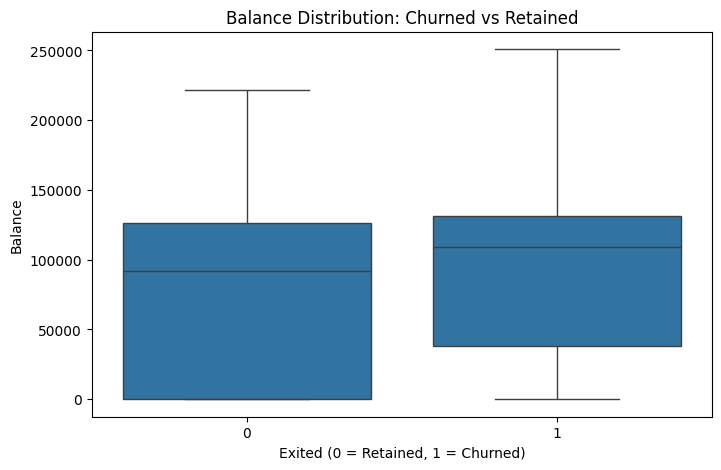

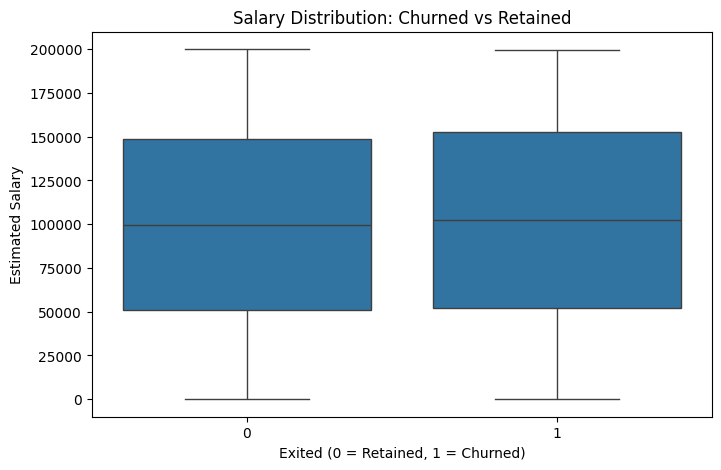

In [ ]:
# ==========================================
# 14. FINANCIAL STABILITY & CHURN ANALYSIS
# ==========================================

# Compare average financial characteristics
financial_profile = (
    df_clean.groupby("Exited")[
        ["CreditScore", "Balance", "EstimatedSalary", "Age", "Tenure"]
    ]
    .mean()
    .round(2)
)

print("Average Customer Profile:")
print(financial_profile)

# Balance vs churn
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x="Exited", y="Balance")
plt.title("Balance Distribution: Churned vs Retained")
plt.xlabel("Exited (0 = Retained, 1 = Churned)")
plt.ylabel("Balance")
plt.show()

# Salary vs churn
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x="Exited", y="EstimatedSalary")
plt.title("Salary Distribution: Churned vs Retained")
plt.xlabel("Exited (0 = Retained, 1 = Churned)")
plt.ylabel("Estimated Salary")
plt.show()

In [ ]:
# ==========================================
# 15. MACHINE LEARNING DATA PREPARATION
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Create ML dataset from original analytical variables
ml_df = df.copy()

# Remove non-predictive identification fields
columns_to_drop = ["Surname"]

if "CustomerId" in ml_df.columns:
    columns_to_drop.append("CustomerId")

ml_df = ml_df.drop(columns=columns_to_drop)

# Convert categorical variables into numerical variables
ml_df = pd.get_dummies(
    ml_df,
    columns=["Geography", "Gender"],
    drop_first=True
)

# Separate features and target
X = ml_df.drop("Exited", axis=1)
y = ml_df["Exited"]

print("Feature columns:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])
print("Target variable:", "Exited")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nMachine learning data preparation completed!")

Feature columns:
['Year', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']

Number of features: 12
Target variable: Exited

Training records: 8000
Testing records: 2000

Machine learning data preparation completed!


In [ ]:
# ==========================================
# 15. MACHINE LEARNING DATA PREPARATION
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Create ML dataset from original analytical variables
ml_df = df.copy()

# Remove non-predictive identification fields
columns_to_drop = ["Surname"]

if "CustomerId" in ml_df.columns:
    columns_to_drop.append("CustomerId")

ml_df = ml_df.drop(columns=columns_to_drop)

# Convert categorical variables into numerical variables
ml_df = pd.get_dummies(
    ml_df,
    columns=["Geography", "Gender"],
    drop_first=True
)

# Separate features and target
X = ml_df.drop("Exited", axis=1)
y = ml_df["Exited"]

print("Feature columns:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])
print("Target variable:", "Exited")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nMachine learning data preparation completed!")

Feature columns:
['Year', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']

Number of features: 12
Target variable: Exited

Training records: 8000
Testing records: 2000

Machine learning data preparation completed!


In [ ]:
# ==========================================
# 16. LOGISTIC REGRESSION
# ==========================================

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained successfully!")
print("Accuracy:", accuracy_score(y_test, log_pred))

Logistic Regression trained successfully!
Accuracy: 0.808


In [ ]:
# ==========================================
# 17. DECISION TREE
# ==========================================

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree trained successfully!")
print("Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree trained successfully!
Accuracy: 0.8605


In [ ]:
# ==========================================
# 18. RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully!")
print("Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest trained successfully!
Accuracy: 0.8435


In [ ]:
# ==========================================
# 19. GRADIENT BOOSTING
# ==========================================

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting trained successfully!")
print("Accuracy:", accuracy_score(y_test, gb_pred))

Gradient Boosting trained successfully!
Accuracy: 0.87


In [ ]:
# ==========================================
# 20. MODEL EVALUATION FUNCTION
# ==========================================

def evaluate_model(model_name, y_true, y_pred, y_prob):

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

print("Evaluation function created successfully!")

Evaluation function created successfully!


In [ ]:
# ==========================================
# 21. EVALUATE ALL MODELS
# ==========================================

results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        log_pred,
        log_prob
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_pred,
        dt_prob
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_pred,
        gb_prob
    )
)

results_df = pd.DataFrame(results)

print("Model evaluation completed!")
results_df

Model evaluation completed!


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8080,0.589147,0.186732,0.283582,0.774778
1,Decision Tree,0.8605,0.775862,0.442260,0.563380,0.840206
2,Random Forest,0.8435,0.607306,0.653563,0.629586,0.863116
3,Gradient Boosting,0.8700,0.800000,0.481572,0.601227,0.870904


                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.8080     0.5891  0.1867    0.2836   0.7748
1        Decision Tree    0.8605     0.7759  0.4423    0.5634   0.8402
2        Random Forest    0.8435     0.6073  0.6536    0.6296   0.8631
3    Gradient Boosting    0.8700     0.8000  0.4816    0.6012   0.8709


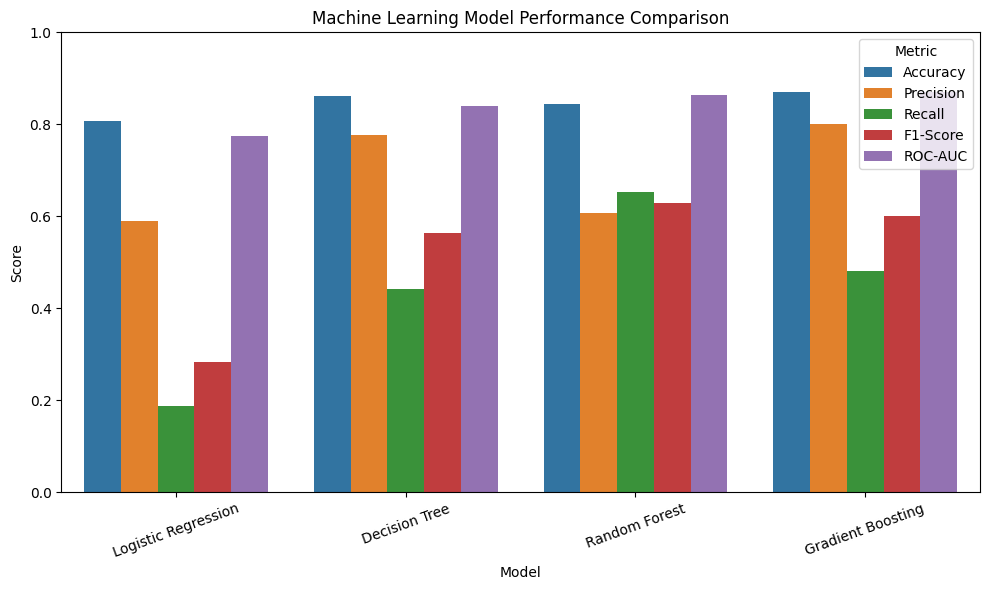

In [ ]:
# ==========================================
# 22. MODEL PERFORMANCE COMPARISON
# ==========================================

results_display = results_df.copy()

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

results_display[metrics] = results_display[metrics].round(4)

print(results_display)

plt.figure(figsize=(10,6))

results_melted = results_display.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Machine Learning Model Performance Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 23. RANDOM FOREST CLASSIFICATION REPORT
# ==========================================

print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Retained", "Churned"],
        zero_division=0
    )
)

Random Forest Classification Report:

              precision    recall  f1-score   support

    Retained       0.91      0.89      0.90      1593
     Churned       0.61      0.65      0.63       407

    accuracy                           0.84      2000
   macro avg       0.76      0.77      0.77      2000
weighted avg       0.85      0.84      0.85      2000



Top features influencing Random Forest predictions:
              Feature  Importance
2                 Age    0.317010
5       NumOfProducts    0.206659
4             Balance    0.118419
8     EstimatedSalary    0.083718
1         CreditScore    0.079936
7      IsActiveMember    0.053197
9   Geography_Germany    0.050986
3              Tenure    0.046291
11        Gender_Male    0.022029
6           HasCrCard    0.011335
10    Geography_Spain    0.010420
0                Year    0.000000


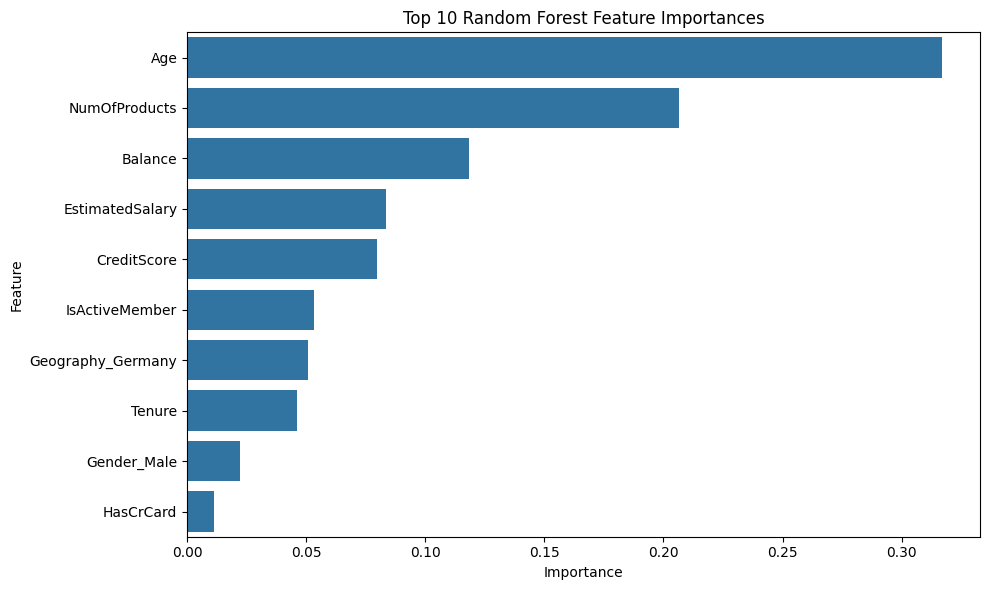

In [ ]:
# ==========================================
# 24. RANDOM FOREST FEATURE IMPORTANCE
# ==========================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top features influencing Random Forest predictions:")
print(feature_importance)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 25. SAVE MODEL & SCALER
# ==========================================

import joblib

# Save Random Forest model
joblib.dump(rf_model, "random_forest.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

print("Random Forest model saved as: random_forest.pkl")
print("Scaler saved as: scaler.pkl")
print("Files are ready for Streamlit deployment!")

Random Forest model saved as: random_forest.pkl
Scaler saved as: scaler.pkl
Files are ready for Streamlit deployment!


Random Forest Confusion Matrix:
[[1421  172]
 [ 141  266]]


<Figure size 700x500 with 0 Axes>

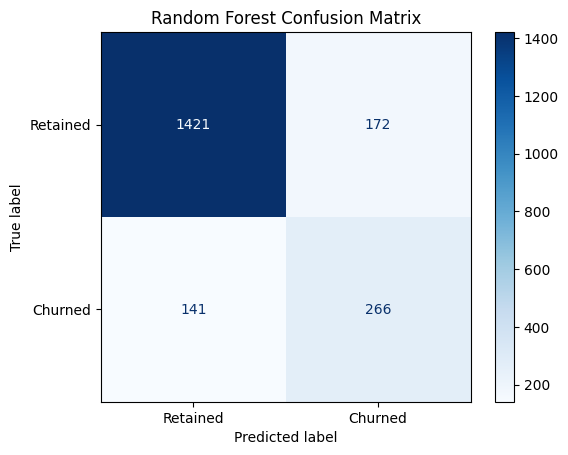

In [ ]:
# ==========================================
# 26. CONFUSION MATRIX
# ==========================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:")
print(cm)

plt.figure(figsize=(7,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Retained", "Churned"]
)

disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

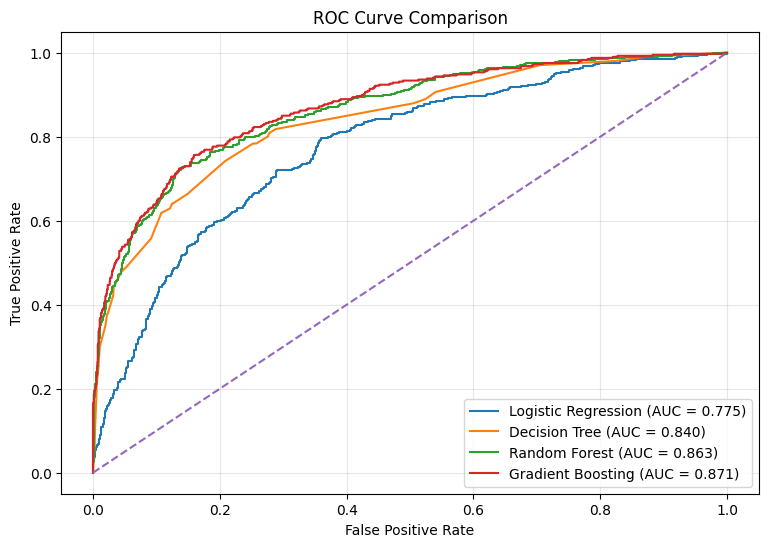

In [ ]:
# ==========================================
# 27. ROC CURVE COMPARISON
# ==========================================

from sklearn.metrics import roc_curve

# Calculate ROC curves
log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(9,6))

plt.plot(
    log_fpr, log_tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, log_prob):.3f})"
)

plt.plot(
    dt_fpr, dt_tpr,
    label=f"Decision Tree (AUC = {roc_auc_score(y_test, dt_prob):.3f})"
)

plt.plot(
    rf_fpr, rf_tpr,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})"
)

plt.plot(
    gb_fpr, gb_tpr,
    label=f"Gradient Boosting (AUC = {roc_auc_score(y_test, gb_prob):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

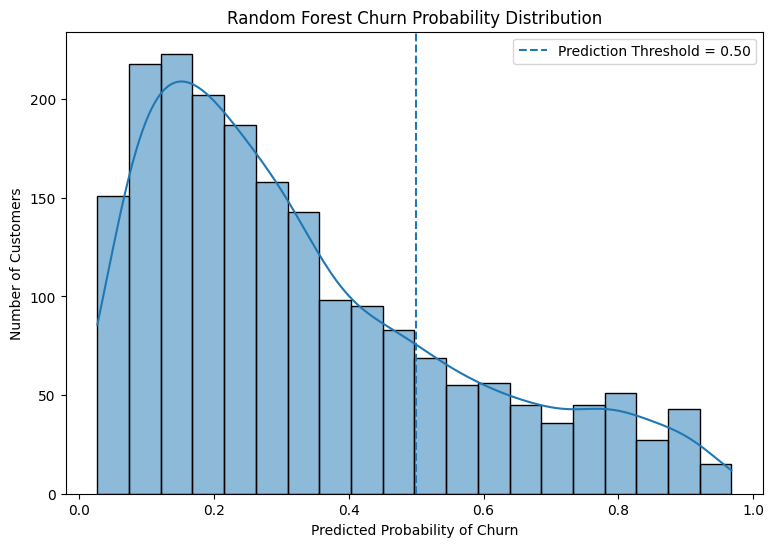

In [ ]:
# ==========================================
# 28. CHURN PROBABILITY DISTRIBUTION
# ==========================================

plt.figure(figsize=(9,6))

sns.histplot(
    rf_prob,
    bins=20,
    kde=True
)

plt.axvline(
    0.5,
    linestyle="--",
    label="Prediction Threshold = 0.50"
)

plt.title("Random Forest Churn Probability Distribution")
plt.xlabel("Predicted Probability of Churn")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

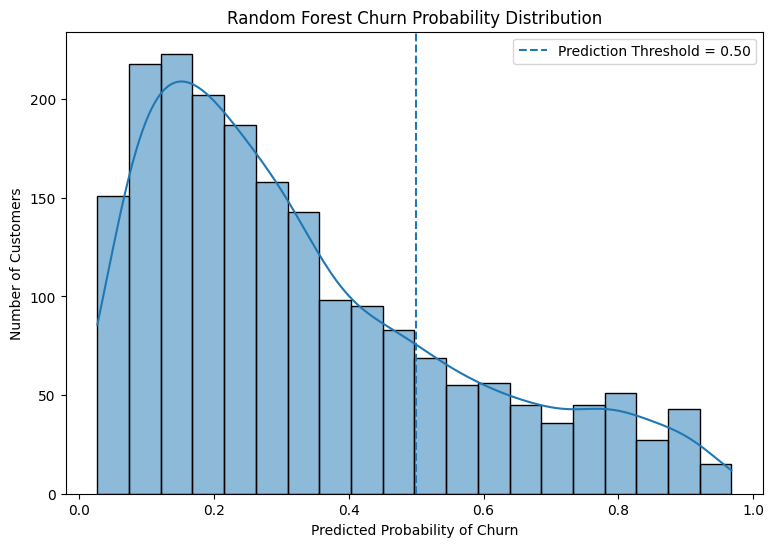

In [ ]:
# ==========================================
# 28. CHURN PROBABILITY DISTRIBUTION
# ==========================================

plt.figure(figsize=(9,6))

sns.histplot(
    rf_prob,
    bins=20,
    kde=True
)

plt.axvline(
    0.5,
    linestyle="--",
    label="Prediction Threshold = 0.50"
)

plt.title("Random Forest Churn Probability Distribution")
plt.xlabel("Predicted Probability of Churn")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

========== CUSTOMER RISK DISTRIBUTION ==========

Risk_Level
Low Risk       1107
Medium Risk     589
High Risk       304
Name: count, dtype: int64

========== CHURN RATE BY RISK LEVEL ==========

    Risk_Level  Churn_Rate_%
0     Low Risk          5.33
1  Medium Risk         22.75
2    High Risk         70.39


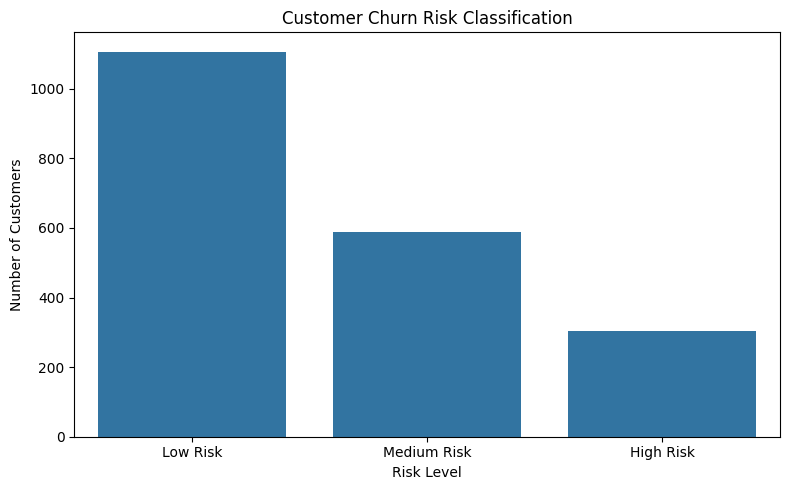

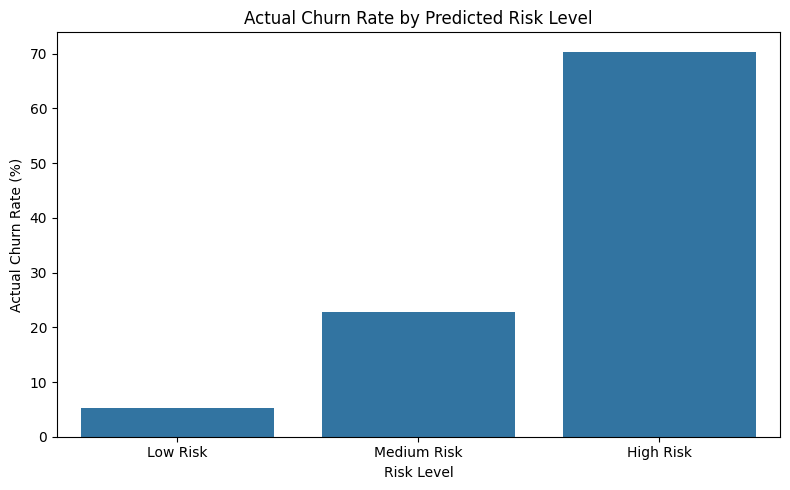

In [ ]:
# ==========================================
# 29-30. CUSTOMER RISK CLASSIFICATION
#          & CHURN RATE BY RISK LEVEL
# ==========================================

# Create risk analysis dataset
risk_df = X_test.copy()

# Add actual churn outcome
risk_df["Actual_Exited"] = y_test.values

# Add Random Forest churn probability
risk_df["Churn_Probability"] = rf_prob

# Classify customers according to predicted churn probability
risk_df["Risk_Level"] = pd.cut(
    risk_df["Churn_Probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# ------------------------------------------
# Customer risk distribution
# ------------------------------------------

print("========== CUSTOMER RISK DISTRIBUTION ==========\n")

print(
    risk_df["Risk_Level"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------
# Churn rate by risk level
# ------------------------------------------

risk_churn = (
    risk_df
    .groupby("Risk_Level", observed=True)["Actual_Exited"]
    .mean()
    .reset_index()
)

risk_churn["Churn_Rate_%"] = (
    risk_churn["Actual_Exited"] * 100
)

print("\n========== CHURN RATE BY RISK LEVEL ==========\n")

print(
    risk_churn[
        ["Risk_Level", "Churn_Rate_%"]
    ].round(2)
)

# ------------------------------------------
# Visualization 1: Risk distribution
# ------------------------------------------

plt.figure(figsize=(8,5))

sns.countplot(
    data=risk_df,
    x="Risk_Level"
)

plt.title("Customer Churn Risk Classification")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

# ------------------------------------------
# Visualization 2: Actual churn rate
# ------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=risk_churn,
    x="Risk_Level",
    y="Churn_Rate_%"
)

plt.title("Actual Churn Rate by Predicted Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Actual Churn Rate (%)")

plt.tight_layout()
plt.show()


   Geography Age_Group    Exited  Churn_Rate_%
0     France       <30  0.051963      5.196305
1     France     30-45  0.118687     11.868687
2     France     46-60  0.457944     45.794393
3     France       60+  0.199134     19.913420
4    Germany       <30  0.126344     12.634409
5    Germany     30-45  0.252957     25.295664
6    Germany     46-60  0.673307     67.330677
7    Germany       60+  0.389381     38.938053
8      Spain       <30  0.079404      7.940447
9      Spain     30-45  0.125160     12.516046
10     Spain     46-60  0.406566     40.656566
11     Spain       60+  0.208333     20.833333


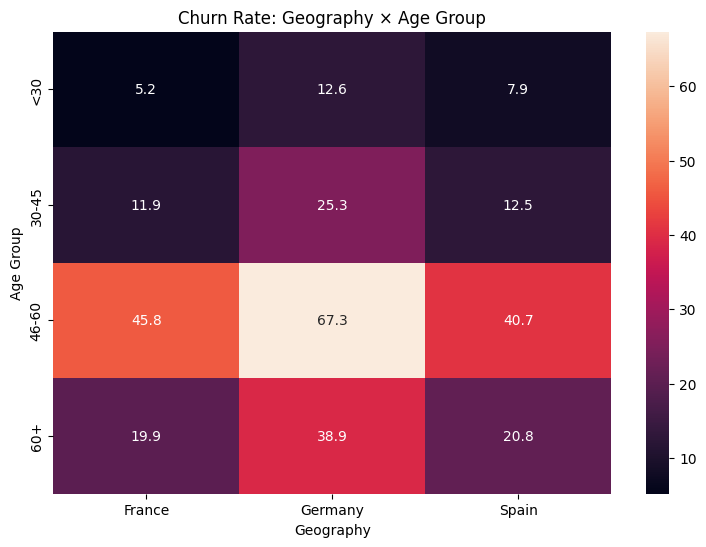

In [ ]:
# ==========================================
# 31. GEOGRAPHY × AGE GROUP CHURN ANALYSIS
# ==========================================

geo_age_churn = (
    df_clean
    .groupby(
        ["Geography", "Age_Group"],
        observed=True
    )["Exited"]
    .mean()
    .reset_index()
)

geo_age_churn["Churn_Rate_%"] = (
    geo_age_churn["Exited"] * 100
)

print(geo_age_churn)

pivot_geo_age = geo_age_churn.pivot(
    index="Age_Group",
    columns="Geography",
    values="Churn_Rate_%"
)

plt.figure(figsize=(9,6))

sns.heatmap(
    pivot_geo_age,
    annot=True,
    fmt=".1f"
)

plt.title("Churn Rate: Geography × Age Group")
plt.xlabel("Geography")
plt.ylabel("Age Group")
plt.show()

  Geography  IsActiveMember    Exited  Churn_Rate_%
0    France               0  0.211308     21.130830
1    France               1  0.115014     11.501351
2   Germany               0  0.410785     41.078509
3   Germany               1  0.237179     23.717949
4     Spain               0  0.233476     23.347639
5     Spain               1  0.107470     10.746951


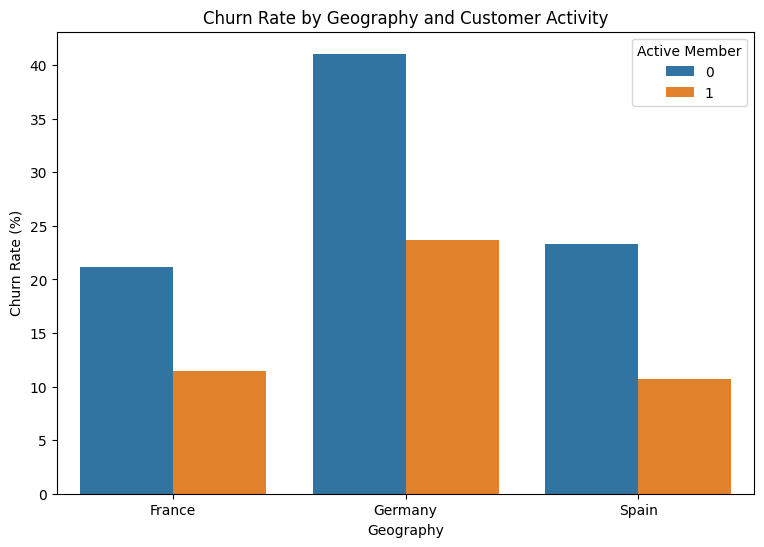

In [ ]:
# ==========================================
# 32. ACTIVITY × GEOGRAPHY CHURN ANALYSIS
# ==========================================

activity_geo = (
    df_clean
    .groupby(
        ["Geography", "IsActiveMember"]
    )["Exited"]
    .mean()
    .reset_index()
)

activity_geo["Churn_Rate_%"] = (
    activity_geo["Exited"] * 100
)

print(activity_geo)

plt.figure(figsize=(9,6))

sns.barplot(
    data=activity_geo,
    x="Geography",
    y="Churn_Rate_%",
    hue="IsActiveMember"
)

plt.title("Churn Rate by Geography and Customer Activity")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")
plt.legend(title="Active Member")

plt.show()

   NumOfProducts  count      mean  Churn_Rate_%
0              1   5084  0.277144     27.714398
1              2   4590  0.075817      7.581699
2              3    266  0.827068     82.706767
3              4     60  1.000000    100.000000


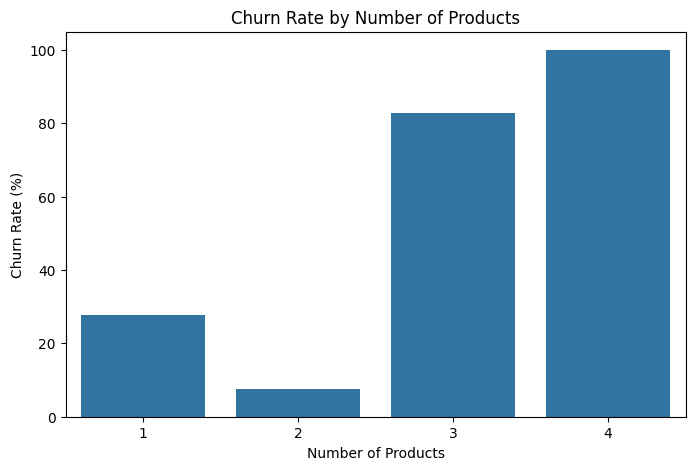

In [ ]:
# ==========================================
# 33. NUMBER OF PRODUCTS VS CHURN
# ==========================================

product_churn = (
    df_clean
    .groupby("NumOfProducts")["Exited"]
    .agg(["count", "mean"])
    .reset_index()
)

product_churn["Churn_Rate_%"] = (
    product_churn["mean"] * 100
)

print(product_churn)

plt.figure(figsize=(8,5))

sns.barplot(
    data=product_churn,
    x="NumOfProducts",
    y="Churn_Rate_%"
)

plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")
plt.show()

Correlation with Churn (Exited):
Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64


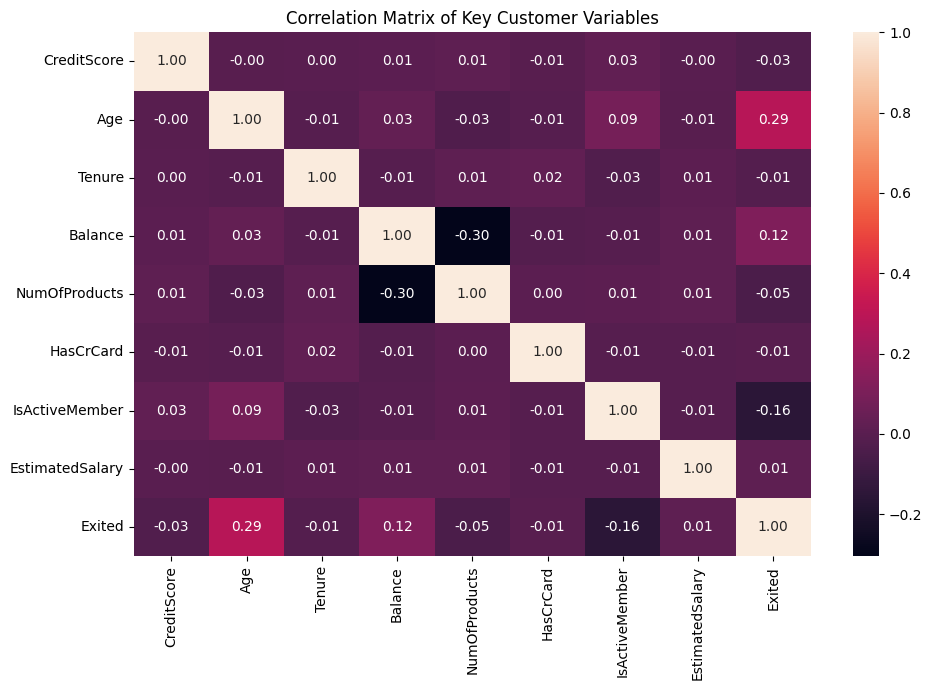

In [ ]:
# ==========================================
# 34. CORRELATION ANALYSIS
# ==========================================

numeric_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "Exited"
]

correlation_matrix = df_clean[numeric_columns].corr()

print("Correlation with Churn (Exited):")
print(
    correlation_matrix["Exited"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Key Customer Variables")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 35. FINAL BUSINESS INSIGHTS
# ==========================================

print("========== CUSTOMER CHURN BUSINESS INSIGHTS ==========\n")

print(f"1. Overall churn rate: {overall_churn_rate:.2f}%")

# Highest-risk geography
highest_geo = geo_churn.loc[
    geo_churn["Churn_Rate_%"].idxmax()
]

print(
    f"2. Highest geographic churn: "
    f"{highest_geo['Geography']} "
    f"({highest_geo['Churn_Rate_%']:.2f}%)"
)

# Highest-risk age group
highest_age = age_churn.loc[
    age_churn["Churn_Rate_%"].idxmax()
]

print(
    f"3. Highest-risk age group: "
    f"{highest_age['Age_Group']} "
    f"({highest_age['Churn_Rate_%']:.2f}%)"
)

# Highest-risk tenure group
highest_tenure = tenure_churn.loc[
    tenure_churn["Churn_Rate_%"].idxmax()
]

print(
    f"4. Highest-risk tenure group: "
    f"{highest_tenure['Tenure_Group']} "
    f"({highest_tenure['Churn_Rate_%']:.2f}%)"
)

# Highest-risk product group
highest_product = product_churn.loc[
    product_churn["Churn_Rate_%"].idxmax()
]

print(
    f"5. Highest-risk product group: "
    f"{int(highest_product['NumOfProducts'])} product(s) "
    f"({highest_product['Churn_Rate_%']:.2f}%)"
)

# High-value customers
high_value_rate = high_value_churn.loc[
    high_value_churn["High_Value_Customer"] == 1,
    "Churn_Rate_%"
].iloc[0]

print(
    f"6. High-value customer churn rate: "
    f"{high_value_rate:.2f}%"
)

print("\n======================================================")
print("Business implication:")
print("Banks can use ML-based risk scores to identify")
print("customers who are more likely to churn and")
print("prioritize targeted retention strategies.")

========== CUSTOMER CHURN BUSINESS INSIGHTS ==========

1. Overall churn rate: 20.37%
2. Highest geographic churn: Germany (32.44%)
3. Highest-risk age group: 46-60 (51.12%)
4. Highest-risk tenure group: New (21.15%)
5. Highest-risk product group: 4 product(s) (100.00%)
6. High-value customer churn rate: 23.68%

Business implication:
Banks can use ML-based risk scores to identify
customers who are more likely to churn and
prioritize targeted retention strategies.


In [ ]:
# ==========================================
# 35. FINAL BUSINESS INSIGHTS
# ==========================================

print("========== CUSTOMER CHURN BUSINESS INSIGHTS ==========\n")

print(f"1. Overall churn rate: {overall_churn_rate:.2f}%")

# Highest-risk geography
highest_geo = geo_churn.loc[
    geo_churn["Churn_Rate_%"].idxmax()
]

print(
    f"2. Highest geographic churn: "
    f"{highest_geo['Geography']} "
    f"({highest_geo['Churn_Rate_%']:.2f}%)"
)

# Highest-risk age group
highest_age = age_churn.loc[
    age_churn["Churn_Rate_%"].idxmax()
]

print(
    f"3. Highest-risk age group: "
    f"{highest_age['Age_Group']} "
    f"({highest_age['Churn_Rate_%']:.2f}%)"
)

# Highest-risk tenure group
highest_tenure = tenure_churn.loc[
    tenure_churn["Churn_Rate_%"].idxmax()
]

print(
    f"4. Highest-risk tenure group: "
    f"{highest_tenure['Tenure_Group']} "
    f"({highest_tenure['Churn_Rate_%']:.2f}%)"
)

# Highest-risk product group
highest_product = product_churn.loc[
    product_churn["Churn_Rate_%"].idxmax()
]

print(
    f"5. Highest-risk product group: "
    f"{int(highest_product['NumOfProducts'])} product(s) "
    f"({highest_product['Churn_Rate_%']:.2f}%)"
)

# High-value customers
high_value_rate = high_value_churn.loc[
    high_value_churn["High_Value_Customer"] == 1,
    "Churn_Rate_%"
].iloc[0]

print(
    f"6. High-value customer churn rate: "
    f"{high_value_rate:.2f}%"
)

print("\n======================================================")
print("Business implication:")
print("Banks can use ML-based risk scores to identify")
print("customers who are more likely to churn and")
print("prioritize targeted retention strategies.")

========== CUSTOMER CHURN BUSINESS INSIGHTS ==========

1. Overall churn rate: 20.37%
2. Highest geographic churn: Germany (32.44%)
3. Highest-risk age group: 46-60 (51.12%)
4. Highest-risk tenure group: New (21.15%)
5. Highest-risk product group: 4 product(s) (100.00%)
6. High-value customer churn rate: 23.68%

Business implication:
Banks can use ML-based risk scores to identify
customers who are more likely to churn and
prioritize targeted retention strategies.


Top 10 features influencing churn:
              Feature  Importance
2                 Age    0.317010
5       NumOfProducts    0.206659
4             Balance    0.118419
8     EstimatedSalary    0.083718
1         CreditScore    0.079936
7      IsActiveMember    0.053197
9   Geography_Germany    0.050986
3              Tenure    0.046291
11        Gender_Male    0.022029
6           HasCrCard    0.011335


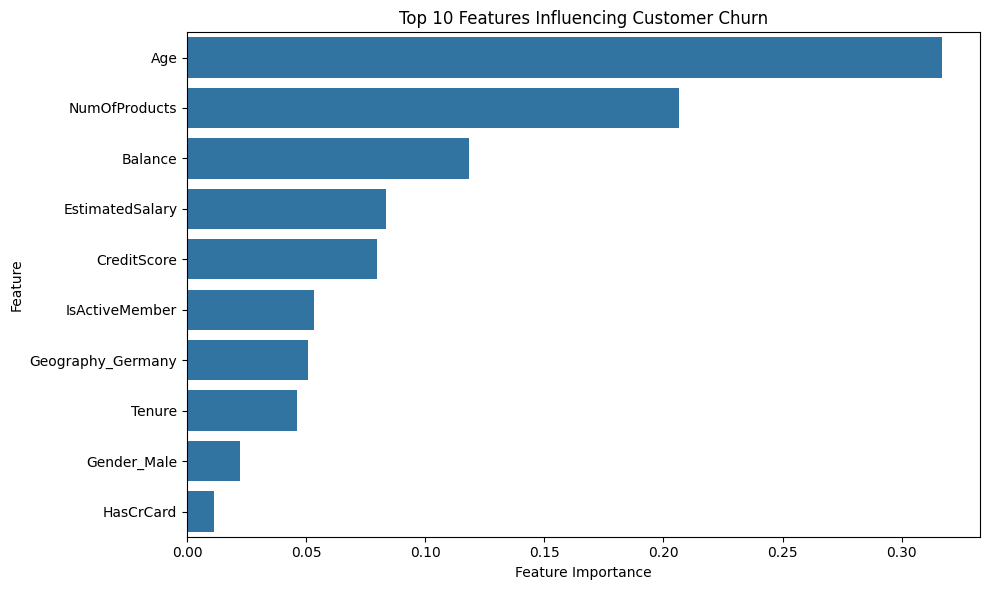

In [ ]:
# ==========================================
# 37. TOP 10 CHURN PREDICTORS
# ==========================================

top_features = feature_importance.head(10).copy()

print("Top 10 features influencing churn:")
print(top_features)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Influencing Customer Churn")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 38. CUSTOMER-LEVEL CHURN PREDICTIONS
# ==========================================

prediction_sample = X_test.copy()

prediction_sample["Actual_Exited"] = y_test.values
prediction_sample["Churn_Probability"] = rf_prob
prediction_sample["Predicted_Exited"] = rf_pred

prediction_sample["Prediction"] = np.where(
    prediction_sample["Predicted_Exited"] == 1,
    "Likely to Churn",
    "Likely to Stay"
)

print("Sample Customer-Level Predictions:\n")

print(
    prediction_sample[
        [
            "Actual_Exited",
            "Churn_Probability",
            "Predicted_Exited",
            "Prediction"
        ]
    ].head(10)
)

Sample Customer-Level Predictions:

      Actual_Exited  Churn_Probability  Predicted_Exited       Prediction
5702              0           0.097203                 0   Likely to Stay
3667              0           0.159309                 0   Likely to Stay
1617              0           0.159379                 0   Likely to Stay
5673              0           0.150162                 0   Likely to Stay
4272              0           0.250159                 0   Likely to Stay
8270              0           0.387606                 0   Likely to Stay
7079              0           0.141191                 0   Likely to Stay
5295              0           0.294585                 0   Likely to Stay
845               0           0.738591                 1  Likely to Churn
5311              0           0.232738                 0   Likely to Stay


In [ ]:
# ==========================================
# 39. HIGH-RISK CUSTOMER IDENTIFICATION
# ==========================================

high_risk_customers = prediction_sample[
    prediction_sample["Churn_Probability"] >= 0.60
].copy()

high_risk_customers = high_risk_customers.sort_values(
    by="Churn_Probability",
    ascending=False
)

print("Number of High-Risk Customers:")
print(len(high_risk_customers))

print("\nTop 20 High-Risk Customers:\n")

print(
    high_risk_customers[
        [
            "Churn_Probability",
            "Actual_Exited",
            "Prediction"
        ]
    ].head(20)
)

Number of High-Risk Customers:
304

Top 20 High-Risk Customers:

      Churn_Probability  Actual_Exited       Prediction
9540           0.967915              1  Likely to Churn
6831           0.950983              1  Likely to Churn
776            0.949628              1  Likely to Churn
70             0.949326              1  Likely to Churn
2168           0.946505              1  Likely to Churn
5010           0.941269              1  Likely to Churn
3639           0.940655              1  Likely to Churn
2220           0.940503              0  Likely to Churn
7008           0.939327              1  Likely to Churn
3549           0.935856              1  Likely to Churn
3827           0.928507              1  Likely to Churn
5922           0.927129              1  Likely to Churn
4137           0.921946              0  Likely to Churn
5701           0.921914              1  Likely to Churn
4732           0.921838              1  Likely to Churn
6303           0.920320              1 

In [ ]:
# ==========================================
# 39. HIGH-RISK CUSTOMER IDENTIFICATION
# ==========================================

high_risk_customers = prediction_sample[
    prediction_sample["Churn_Probability"] >= 0.60
].copy()

high_risk_customers = high_risk_customers.sort_values(
    by="Churn_Probability",
    ascending=False
)

print("Number of High-Risk Customers:")
print(len(high_risk_customers))

print("\nTop 20 High-Risk Customers:\n")

print(
    high_risk_customers[
        [
            "Churn_Probability",
            "Actual_Exited",
            "Prediction"
        ]
    ].head(20)
)

Number of High-Risk Customers:
304

Top 20 High-Risk Customers:

      Churn_Probability  Actual_Exited       Prediction
9540           0.967915              1  Likely to Churn
6831           0.950983              1  Likely to Churn
776            0.949628              1  Likely to Churn
70             0.949326              1  Likely to Churn
2168           0.946505              1  Likely to Churn
5010           0.941269              1  Likely to Churn
3639           0.940655              1  Likely to Churn
2220           0.940503              0  Likely to Churn
7008           0.939327              1  Likely to Churn
3549           0.935856              1  Likely to Churn
3827           0.928507              1  Likely to Churn
5922           0.927129              1  Likely to Churn
4137           0.921946              0  Likely to Churn
5701           0.921914              1  Likely to Churn
4732           0.921838              1  Likely to Churn
6303           0.920320              1 

In [ ]:
# ==========================================
# 41. PRODUCT USAGE & CHURN ANALYSIS
# ==========================================

product_analysis = (
    df_clean
    .groupby("NumOfProducts")["Exited"]
    .agg(
        Customers="count",
        Churned="sum",
        Churn_Rate="mean"
    )
    .reset_index()
)

product_analysis["Churn_Rate_%"] = (
    product_analysis["Churn_Rate"] * 100
)

print("Product Usage & Churn Analysis:\n")

print(
    product_analysis[
        [
            "NumOfProducts",
            "Customers",
            "Churned",
            "Churn_Rate_%"
        ]
    ].round(2)
)

Product Usage & Churn Analysis:

   NumOfProducts  Customers  Churned  Churn_Rate_%
0              1       5084     1409         27.71
1              2       4590      348          7.58
2              3        266      220         82.71
3              4         60       60        100.00


In [ ]:
# ==========================================
# 42. CUSTOMER ENGAGEMENT ANALYSIS
# ==========================================

engagement_analysis = (
    df_clean
    .groupby("IsActiveMember")["Exited"]
    .agg(
        Customers="count",
        Churned="sum",
        Churn_Rate="mean"
    )
    .reset_index()
)

engagement_analysis["Churn_Rate_%"] = (
    engagement_analysis["Churn_Rate"] * 100
)

engagement_analysis["Activity_Status"] = np.where(
    engagement_analysis["IsActiveMember"] == 1,
    "Active",
    "Inactive"
)

print("Customer Engagement Analysis:\n")

print(
    engagement_analysis[
        [
            "Activity_Status",
            "Customers",
            "Churned",
            "Churn_Rate_%"
        ]
    ].round(2)
)

Customer Engagement Analysis:

  Activity_Status  Customers  Churned  Churn_Rate_%
0        Inactive       4849     1302         26.85
1          Active       5151      735         14.27


In [ ]:
# ==========================================
# 42. CUSTOMER ENGAGEMENT ANALYSIS
# ==========================================

engagement_analysis = (
    df_clean
    .groupby("IsActiveMember")["Exited"]
    .agg(
        Customers="count",
        Churned="sum",
        Churn_Rate="mean"
    )
    .reset_index()
)

engagement_analysis["Churn_Rate_%"] = (
    engagement_analysis["Churn_Rate"] * 100
)

engagement_analysis["Activity_Status"] = np.where(
    engagement_analysis["IsActiveMember"] == 1,
    "Active",
    "Inactive"
)

print("Customer Engagement Analysis:\n")

print(
    engagement_analysis[
        [
            "Activity_Status",
            "Customers",
            "Churned",
            "Churn_Rate_%"
        ]
    ].round(2)
)

Customer Engagement Analysis:

  Activity_Status  Customers  Churned  Churn_Rate_%
0        Inactive       4849     1302         26.85
1          Active       5151      735         14.27


In [ ]:
# ==========================================
# 43. HIGH-VALUE CUSTOMER RISK ANALYSIS
# ==========================================

high_value_analysis = (
    df_clean
    .groupby("High_Value_Customer")["Exited"]
    .agg(
        Customers="count",
        Churned="sum",
        Churn_Rate="mean"
    )
    .reset_index()
)

high_value_analysis["Churn_Rate_%"] = (
    high_value_analysis["Churn_Rate"] * 100
)

high_value_analysis["Customer_Type"] = np.where(
    high_value_analysis["High_Value_Customer"] == 1,
    "High-Value",
    "Regular"
)

print("High-Value Customer Risk Analysis:\n")

print(
    high_value_analysis[
        [
            "Customer_Type",
            "Customers",
            "Churned",
            "Churn_Rate_%"
        ]
    ].round(2)
)

High-Value Customer Risk Analysis:

  Customer_Type  Customers  Churned  Churn_Rate_%
0       Regular       7500     1445         19.27
1    High-Value       2500      592         23.68


In [ ]:
# ==========================================
# 44. BUSINESS RECOMMENDATIONS
# ==========================================

print("========== BUSINESS RECOMMENDATIONS ==========\n")

print("1. PRIORITIZE HIGH-RISK CUSTOMERS")
print(
    "Use Random Forest churn probabilities to identify "
    "customers requiring immediate retention attention."
)

print("\n2. IMPROVE CUSTOMER ENGAGEMENT")
print(
    "Inactive customers should be targeted with personalized "
    "offers, communication and digital engagement campaigns."
)

print("\n3. FOCUS ON HIGH-RISK SEGMENTS")
print(
    "Use geography, age, tenure, balance and product usage "
    "to design segment-specific retention strategies."
)

print("\n4. PROTECT HIGH-VALUE CUSTOMERS")
print(
    "Customers with high balances and high churn probability "
    "should receive priority retention treatment."
)

print("\n5. USE PREDICTIVE ANALYTICS")
print(
    "The bank can use churn probability scores to move from "
    "reactive customer retention to proactive intervention."
)

========== BUSINESS RECOMMENDATIONS ==========

1. PRIORITIZE HIGH-RISK CUSTOMERS
Use Random Forest churn probabilities to identify customers requiring immediate retention attention.

2. IMPROVE CUSTOMER ENGAGEMENT
Inactive customers should be targeted with personalized offers, communication and digital engagement campaigns.

3. FOCUS ON HIGH-RISK SEGMENTS
Use geography, age, tenure, balance and product usage to design segment-specific retention strategies.

4. PROTECT HIGH-VALUE CUSTOMERS
Customers with high balances and high churn probability should receive priority retention treatment.

5. USE PREDICTIVE ANALYTICS
The bank can use churn probability scores to move from reactive customer retention to proactive intervention.


In [ ]:
# ==========================================
# 44. BUSINESS RECOMMENDATIONS
# ==========================================

print("========== BUSINESS RECOMMENDATIONS ==========\n")

print("1. PRIORITIZE HIGH-RISK CUSTOMERS")
print(
    "Use Random Forest churn probabilities to identify "
    "customers requiring immediate retention attention."
)

print("\n2. IMPROVE CUSTOMER ENGAGEMENT")
print(
    "Inactive customers should be targeted with personalized "
    "offers, communication and digital engagement campaigns."
)

print("\n3. FOCUS ON HIGH-RISK SEGMENTS")
print(
    "Use geography, age, tenure, balance and product usage "
    "to design segment-specific retention strategies."
)

print("\n4. PROTECT HIGH-VALUE CUSTOMERS")
print(
    "Customers with high balances and high churn probability "
    "should receive priority retention treatment."
)

print("\n5. USE PREDICTIVE ANALYTICS")
print(
    "The bank can use churn probability scores to move from "
    "reactive customer retention to proactive intervention."
)

========== BUSINESS RECOMMENDATIONS ==========

1. PRIORITIZE HIGH-RISK CUSTOMERS
Use Random Forest churn probabilities to identify customers requiring immediate retention attention.

2. IMPROVE CUSTOMER ENGAGEMENT
Inactive customers should be targeted with personalized offers, communication and digital engagement campaigns.

3. FOCUS ON HIGH-RISK SEGMENTS
Use geography, age, tenure, balance and product usage to design segment-specific retention strategies.

4. PROTECT HIGH-VALUE CUSTOMERS
Customers with high balances and high churn probability should receive priority retention treatment.

5. USE PREDICTIVE ANALYTICS
The bank can use churn probability scores to move from reactive customer retention to proactive intervention.


In [ ]:
# Cell 45 - Executive Summary (Independent Version)

print("========== EXECUTIVE SUMMARY ==========\n")

print("Project: Customer Churn Prediction in European Banking Using Machine Learning\n")

# -----------------------------
# 1. Model Performance
# -----------------------------

print("MODEL PERFORMANCE\n")

# Check the models that already exist
models_available = []

if 'log_model' in globals():
    models_available.append(("Logistic Regression", log_model, log_prob))

if 'dt_model' in globals():
    models_available.append(("Decision Tree", dt_model, dt_prob))

if 'rf_model' in globals():
    models_available.append(("Random Forest", rf_model, rf_prob))

if 'gb_model' in globals():
    models_available.append(("Gradient Boosting", gb_model, gb_prob))

# Calculate ROC-AUC directly
from sklearn.metrics import roc_auc_score

model_scores = []

for name, model, probability in models_available:
    auc = roc_auc_score(y_test, probability)
    model_scores.append([name, auc])

model_scores_df = pd.DataFrame(
    model_scores,
    columns=["Model", "ROC-AUC"]
).sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

print(model_scores_df.round(3))

# Best model
best_model_name = model_scores_df.iloc[0]["Model"]

print("\nBest Performing Model:")
print(best_model_name)


# -----------------------------
# 2. High-Risk Customers
# -----------------------------

print("\nHIGH-RISK CUSTOMER ANALYSIS\n")

# Calculate directly from RF probabilities
high_risk_count = (rf_prob >= 0.60).sum()
total_customers = len(rf_prob)

high_risk_percentage = (
    high_risk_count / total_customers
) * 100

print("Total customers evaluated:", total_customers)
print("High-risk customers:", high_risk_count)
print("High-risk percentage:", round(high_risk_percentage, 2), "%")


# -----------------------------
# 3. Key Insights
# -----------------------------

print("\nKEY BUSINESS INSIGHTS\n")

print("1. Machine learning can identify customers with a higher probability of churn.")
print("2. Customer demographics, engagement, product usage and financial characteristics are associated with churn.")
print("3. High-risk customers can be prioritized for targeted retention strategies.")
print("4. Model-based churn probabilities can help banks focus retention efforts on customers most likely to leave.")


# -----------------------------
# 4. Recommendation
# -----------------------------

print("\nBUSINESS RECOMMENDATION\n")

print(
    "Banks should use customer churn probabilities to identify high-risk "
    "customers and implement targeted retention strategies such as "
    "personalized offers, improved engagement and relationship management."
)

print("\n========== END OF EXECUTIVE SUMMARY ==========")

========== EXECUTIVE SUMMARY ==========

Project: Customer Churn Prediction in European Banking Using Machine Learning

MODEL PERFORMANCE

                 Model  ROC-AUC
0    Gradient Boosting    0.871
1        Random Forest    0.863
2        Decision Tree    0.840
3  Logistic Regression    0.775

Best Performing Model:
Gradient Boosting

HIGH-RISK CUSTOMER ANALYSIS

Total customers evaluated: 2000
High-risk customers: 304
High-risk percentage: 15.2 %

KEY BUSINESS INSIGHTS

1. Machine learning can identify customers with a higher probability of churn.
2. Customer demographics, engagement, product usage and financial characteristics are associated with churn.
3. High-risk customers can be prioritized for targeted retention strategies.
4. Model-based churn probabilities can help banks focus retention efforts on customers most likely to leave.

BUSINESS RECOMMENDATION

Banks should use customer churn probabilities to identify high-risk customers and implement targeted retention strategi

In [ ]:
# ==========================================
# 46. SAVE MODEL PERFORMANCE
# ==========================================

results_df.to_csv(
    "model_performance.csv",
    index=False
)

print("Model performance saved successfully.")
print("File: model_performance.csv")

Model performance saved successfully.
File: model_performance.csv


In [ ]:
# ==========================================
# 47. SAVE FEATURE IMPORTANCE
# ==========================================

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")
print("File: feature_importance.csv")

Feature importance saved successfully.
File: feature_importance.csv


In [ ]:
# ==========================================
# 48. SAVE CUSTOMER RISK PREDICTIONS
# ==========================================

risk_df.to_csv(
    "customer_risk_predictions.csv",
    index=False
)

print("Customer risk predictions saved successfully.")
print("File: customer_risk_predictions.csv")

Customer risk predictions saved successfully.
File: customer_risk_predictions.csv


In [ ]:
# ==========================================
# 49. SAVE HIGH-RISK CUSTOMERS
# ==========================================

high_risk_customers.to_csv(
    "high_risk_customers.csv",
    index=False
)

print("High-risk customer data saved successfully.")
print("File: high_risk_customers.csv")

High-risk customer data saved successfully.
File: high_risk_customers.csv


In [ ]:
# ==========================================
# 50. FINAL PROJECT COMPLETION CHECK
# ==========================================

print("======================================================")
print("     CUSTOMER CHURN PREDICTION PROJECT")
print("======================================================\n")

print("PROJECT STATUS: COMPLETED\n")

print("✓ Data ingestion and validation")
print("✓ Data cleaning and preparation")
print("✓ Customer segmentation")
print("✓ Exploratory data analysis")
print("✓ Churn analysis")
print("✓ Geographic and demographic analysis")
print("✓ High-value customer analysis")
print("✓ Machine learning model development")
print("✓ Logistic Regression")
print("✓ Decision Tree")
print("✓ Random Forest")
print("✓ Gradient Boosting")
print("✓ Model performance evaluation")
print("✓ ROC-AUC comparison")
print("✓ Feature importance analysis")
print("✓ Customer risk classification")
print("✓ High-risk customer identification")
print("✓ Business recommendations")
print("✓ Results exported")

print("\n------------------------------------------------------")

print(f"Best Model: {best_model_name}")
print(f"Overall Churn Rate: {overall_churn_rate:.2f}%")
print(f"High-Risk Customers: {high_risk_count}")

print("\n------------------------------------------------------")

print("Analysis notebook completed successfully!")

print("======================================================")

     CUSTOMER CHURN PREDICTION PROJECT

PROJECT STATUS: COMPLETED

✓ Data ingestion and validation
✓ Data cleaning and preparation
✓ Customer segmentation
✓ Exploratory data analysis
✓ Churn analysis
✓ Geographic and demographic analysis
✓ High-value customer analysis
✓ Machine learning model development
✓ Logistic Regression
✓ Decision Tree
✓ Random Forest
✓ Gradient Boosting
✓ Model performance evaluation
✓ ROC-AUC comparison
✓ Feature importance analysis
✓ Customer risk classification
✓ High-risk customer identification
✓ Business recommendations
✓ Results exported

------------------------------------------------------
Best Model: Gradient Boosting
Overall Churn Rate: 20.37%
High-Risk Customers: 304

------------------------------------------------------
Analysis notebook completed successfully!
